# Homework 5 Problem 1: ViT vs. ResNet-18

**Course:** ECGR 4106  
**Student:** Gilberto Feliu  
**Student ID:** 801257813  
**Dataset:** CIFAR-100

This notebook reports the current Problem 1 experiment artifacts from `Results_Problem_1`. Problem 1 now has completed 10-epoch rows for all four ViT configurations and the ResNet-18 baseline.

## Experiment Setup

The custom Vision Transformer uses convolutional patch embedding, a learned class token, learned positional embeddings, `nn.TransformerEncoderLayer` blocks, layer normalization, and a linear classifier head for 100 CIFAR-100 classes. The ResNet-18 baseline uses `torchvision.models.resnet18(weights=None)` with the first convolution changed for 32 by 32 CIFAR images and the initial max-pooling layer removed.

All runs use CIFAR-100 normalization, Adam optimization, cross-entropy loss, batch size 64, and a 10-epoch schedule. The current CSV contains the completed 10-epoch Problem 1 results.

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd()
RESULTS = ROOT / 'Results_Problem_1'
history_path = RESULTS / 'problem1_history.csv'
summary_path = RESULTS / 'problem1_summary.csv'
plot_path = RESULTS / 'problem1_loss_curves.png'
print('Summary:', summary_path)
print('History:', history_path)
print('Plot:', plot_path)

Summary: /home/gilberto/Homework_5/Results_Problem_1/problem1_summary.csv
History: /home/gilberto/Homework_5/Results_Problem_1/problem1_history.csv
Plot: /home/gilberto/Homework_5/Results_Problem_1/problem1_loss_curves.png


## Summary Results

The table below is read directly from `Results_Problem_1/problem1_summary.csv`. Static values such as parameters and FLOPs are filled for all configured models; training-dependent fields are present only for completed runs.

In [2]:
summary_df = pd.read_csv(summary_path, keep_default_na=False)
summary_df

,model_name,patch_size,embed_dim,depth,heads,mlp_dim,parameter_count,flops_forward,train_time_per_epoch_sec,final_train_loss,final_val_loss,test_accuracy_pct,notes
0,vit_patch4_dim256_d4_h4,4,256,4,4,1024,3214692,2.131507e+08,23.014994,3.325062,3.283429,20.01,device=cuda
1,vit_patch4_dim512_d8_h8,4,512,8,8,2048,25330276,1.670441e+09,106.715145,4.303222,4.323157,4.51,device=cuda
2,vit_patch8_dim256_d4_h4,8,256,4,4,1024,3239268,5.409485e+07,12.217159,3.902182,3.885059,9.68,device=cuda
3,vit_patch8_dim512_d8_h8,8,512,8,8,2048,25379428,4.302377e+08,42.299152,4.227836,4.269351,4.95,device=cuda
4,resnet18,,,,,,11220132,1.100000e+09,61.236564,1.048969,1.391882,61.20,device=cuda


## Clean Report Table

In [3]:
report_cols = [
    'model_name', 'parameter_count', 'flops_forward',
    'train_time_per_epoch_sec', 'final_val_loss', 'test_accuracy_pct', 'notes'
]
report_df = summary_df[report_cols].copy()
report_df.columns = ['Model', 'Params', 'FLOPs / Forward', 'Time / Epoch (s)', 'Final Val Loss', 'Test Accuracy (%)', 'Status']
report_df

,Model,Params,FLOPs / Forward,Time / Epoch (s),Final Val Loss,Test Accuracy (%),Status
0,vit_patch4_dim256_d4_h4,3214692,2.131507e+08,23.014994,3.283429,20.01,device=cuda
1,vit_patch4_dim512_d8_h8,25330276,1.670441e+09,106.715145,4.323157,4.51,device=cuda
2,vit_patch8_dim256_d4_h4,3239268,5.409485e+07,12.217159,3.885059,9.68,device=cuda
3,vit_patch8_dim512_d8_h8,25379428,4.302377e+08,42.299152,4.269351,4.95,device=cuda
4,resnet18,11220132,1.100000e+09,61.236564,1.391882,61.20,device=cuda


## Per-Epoch History

A full Problem 1 run should produce about 50 data rows: 5 models times 10 epochs. The current history file contains the completed Problem 1 runs.

In [4]:
history_df = pd.read_csv(history_path)
print(f'History rows: {len(history_df)}')
history_df

History rows: 50


,model_name,epoch,train_loss,val_loss,train_accuracy_pct,val_accuracy_pct,epoch_seconds
0,vit_patch4_dim256_d4_h4,1,4.010155,3.759034,7.828,11.36,23.015639
1,vit_patch4_dim256_d4_h4,2,3.738646,3.665595,11.850,13.50,22.786489
2,vit_patch4_dim256_d4_h4,3,3.640890,3.556376,13.436,14.62,22.918571
3,vit_patch4_dim256_d4_h4,4,3.606052,3.507664,14.038,16.03,23.130308
4,vit_patch4_dim256_d4_h4,5,3.554222,3.522711,14.900,16.13,23.087703
5,vit_patch4_dim256_d4_h4,6,3.535617,3.425678,15.396,17.34,22.934365
6,vit_patch4_dim256_d4_h4,7,3.436794,3.465146,17.226,17.02,22.914715
7,vit_patch4_dim256_d4_h4,8,3.438895,3.348804,17.018,18.73,23.025334
8,vit_patch4_dim256_d4_h4,9,3.347852,3.299602,18.770,19.72,23.194426
9,vit_patch4_dim256_d4_h4,10,3.325062,3.283429,19.102,20.01,23.141071


## Loss Curves

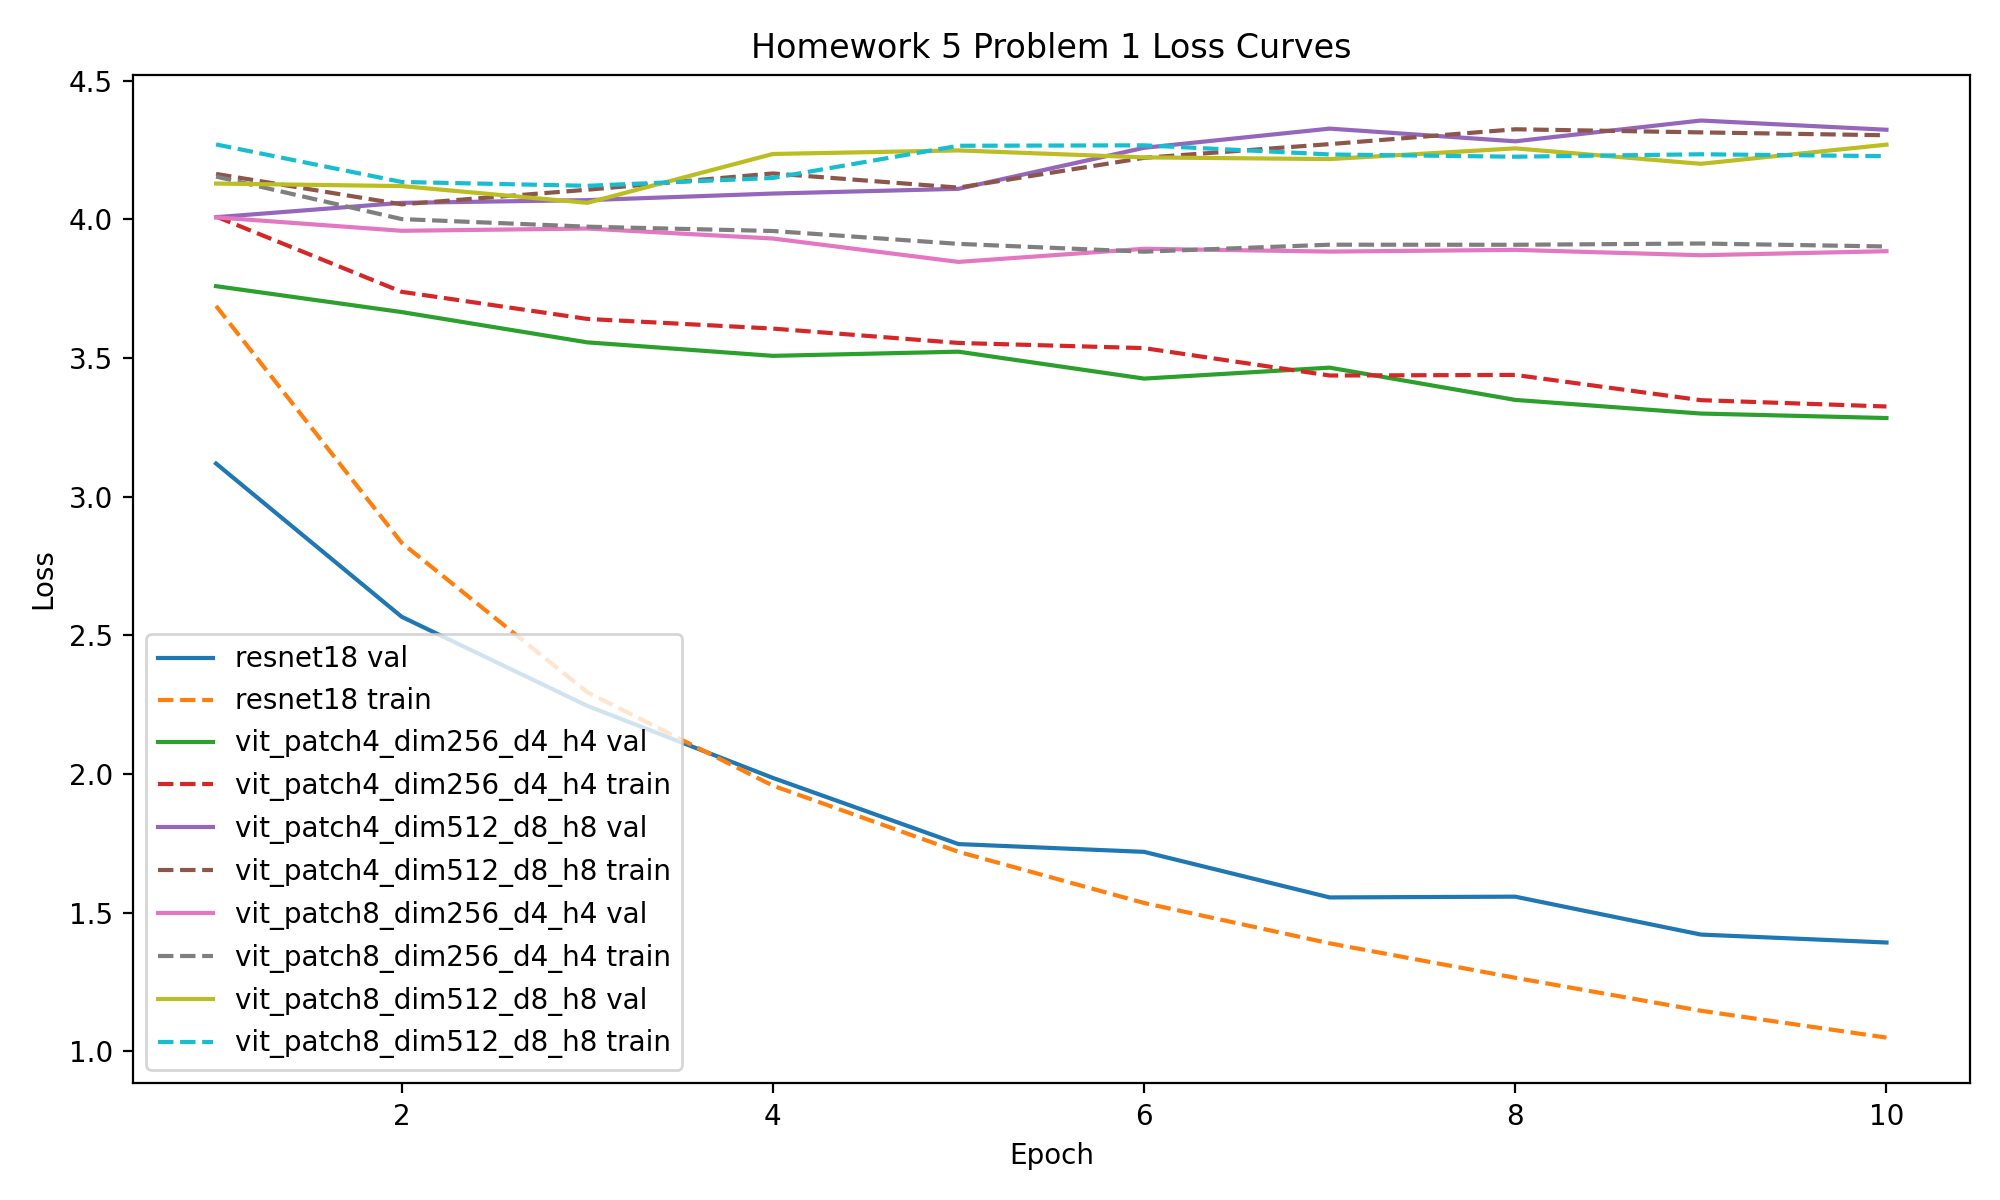

In [5]:
display(Image(filename=str(plot_path)))

## Interpretation

Among the ViT models, `vit_patch4_dim256_d4_h4` performs best at 20.01% test accuracy. `vit_patch8_dim256_d4_h4` is the next best ViT at 9.68% and has the lowest estimated FLOP count. The larger ViT-B and ViT-D models have many more parameters but perform poorly under this short 10-epoch from-scratch schedule.

The ResNet-18 baseline is strongest overall at 61.20% test accuracy. That is consistent with convolutional inductive bias helping on CIFAR-100, while from-scratch ViTs generally need longer schedules, stronger regularization, or pretraining.